# Evidence Fusion & Timeline

**InterviewLens · MSADS Advanced Computer Vision (31023) · Final Project**

This notebook implements the **Evidence Fusion & Timeline** stage of the InterviewLens architecture (see `pipeline_final.jpeg`): it takes Notebook 1's `pose_evidence.json` and Notebook 2's `background_evidence.json` — two streams sampled at different rates, about different aspects of the same video — and fuses them onto one common timeline.

## What this notebook does

1. Loads both evidence files and verifies they reference the **same** demo video (via `shared_video.py`'s checksum guard — see `CLAUDE.md` > "Shared demo video").
2. Builds a common time grid at the *coarser* of the two sample rates (resampling, not forcing one stream's rate onto the other's raw data — per `SKILLS.md` > "Evidence fusion").
3. Resamples the pose/framing stream onto that grid and derives simple framing flags (tight/loose headroom, off-center, tilted) from documented heuristic thresholds.
4. Resamples the background stream onto the grid by checking, per grid point, which tracks' `[start_s, end_s]` window covers it.
5. Writes the fused, per-timestamp evidence package to `outputs/fused_evidence.json` — every entry carries the timestamp plus the raw measurement backing it, not just a conclusion (the rule the out-of-scope Evidence Validation layer will later enforce).
6. Renders a broken-barh timeline chart (pose flags vs. background tier presence).

Everything past this point in the full architecture (VLM reasoning, evidence validation, final coaching report) is out of scope for this delivery — see `CLAUDE.md`.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from shared_video import current_run_dir, load_verified_video_path

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
for d in (DATA_DIR, OUTPUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Same checksum-verified video both upstream notebooks used -- guarantees this fusion
# isn't silently combining evidence extracted from two different videos.
DEMO_VIDEO_PATH = load_verified_video_path(DATA_DIR)

# Same per-run output directory Notebooks 1 and 2 wrote into -- see shared_video.py.
OUTPUT_DIR = current_run_dir(OUTPUT_DIR)
print(f"Fusing evidence for: {DEMO_VIDEO_PATH.name}")
print(f"Run output directory: {OUTPUT_DIR}")

Fusing evidence for: test.mp4
Run output directory: outputs/test_20260811_184726


## 2. Load Pose & Background Evidence

Both files must exist (Notebooks 1 and 2 must have run first, in order) and must name the same video — a cheap sanity check on top of the checksum guard, since it's the video *filename* embedded in each evidence file, written at extraction time.

In [2]:
POSE_EVIDENCE_PATH = OUTPUT_DIR / "pose_evidence.json"
BACKGROUND_EVIDENCE_PATH = OUTPUT_DIR / "background_evidence.json"
assert POSE_EVIDENCE_PATH.exists(), "Run Notebook 1 first to produce pose_evidence.json"
assert BACKGROUND_EVIDENCE_PATH.exists(), "Run Notebook 2 first to produce background_evidence.json"

with open(POSE_EVIDENCE_PATH) as f:
    pose_evidence = json.load(f)
with open(BACKGROUND_EVIDENCE_PATH) as f:
    background_evidence = json.load(f)

assert pose_evidence["video"] == background_evidence["video"] == DEMO_VIDEO_PATH.name, (
    f"Evidence files were extracted from different videos: "
    f"pose={pose_evidence['video']!r}, background={background_evidence['video']!r}, "
    f"current={DEMO_VIDEO_PATH.name!r}. Re-run Notebooks 1 and 2 against the current video."
)

POSE_FPS = pose_evidence["fps_sampled"]
BG_FPS = background_evidence["fps_sampled"]
print(f"Pose stream:       {len(pose_evidence['frames'])} frames @ {POSE_FPS} fps")
print(f"Background stream: {len(background_evidence['detections'])} tracks @ {BG_FPS} fps")

Pose stream:       125 frames @ 5 fps
Background stream: 3 tracks @ 3 fps


## 3. Common Timeline Grid

The two streams were sampled at different rates (pose finer, background coarser). Rather than snapping the finer stream onto the coarser one's raw timestamps (which would silently throw away real pose samples) or interpolating the coarser stream up to the finer rate (which would fabricate precision background tracking never had), we build a **new, independent grid at the coarser rate** and resample both streams onto it — per `SKILLS.md`'s fusion guidance.

In [3]:
FUSION_FPS = min(POSE_FPS, BG_FPS)  # coarser stream is the true temporal resolution limit
video_duration_s = pose_evidence["frames"][-1]["timestamp_s"]
fusion_grid = np.round(np.arange(0.0, video_duration_s + 1e-6, 1.0 / FUSION_FPS), 3)
print(f"Fusion grid: {FUSION_FPS} fps, {len(fusion_grid)} timestamps, 0.0s - {fusion_grid[-1]:.2f}s")

Fusion grid: 3 fps, 75 timestamps, 0.0s - 24.67s


## 4. Resample Pose/Framing Stream

For each grid timestamp, take the nearest pose sample (within half a pose-frame interval) and derive framing flags from simple, documented heuristic thresholds — these are standard video-framing conventions (not fit to a labeled dataset), called out explicitly here rather than presented as ground truth:

- **Headroom**: ideal range ~5%-25% of frame height above the subject; `too_tight` below, `too_loose` above.
- **Centering**: ideal within ±15% of frame center (normalized offset); else `off_center`.
- **Roll**: ideal within ±10°; else `tilted`.
- **Hand-to-face**: derived from Notebook 1's per-frame `gesture` field (a local dip in a wrist's own keypoint confidence, not a distance threshold -- see Notebook 1 §8.1); surfaced here as `hand_near_face`.

In [4]:
HEADROOM_MIN, HEADROOM_MAX = 0.05, 0.25
CENTERING_MAX_OFFSET = 0.15
ROLL_MAX_DEG = 10.0

pose_by_ts = {fr["timestamp_s"]: fr for fr in pose_evidence["frames"]}
pose_timestamps = np.array(sorted(pose_by_ts.keys()))
POSE_TOLERANCE_S = 0.5 / POSE_FPS


def nearest_pose_frame(ts: float):
    idx = int(np.argmin(np.abs(pose_timestamps - ts)))
    nearest_ts = pose_timestamps[idx]
    if abs(nearest_ts - ts) > POSE_TOLERANCE_S + (1.0 / FUSION_FPS):
        return None
    return pose_by_ts[nearest_ts]


def framing_flags(framing: dict) -> list[str]:
    if framing is None or framing.get("bbox") is None:
        return ["no_subject_detected"]
    flags = []
    headroom = framing["headroom_pct"]
    if headroom is not None:
        if headroom < HEADROOM_MIN:
            flags.append("headroom_too_tight")
        elif headroom > HEADROOM_MAX:
            flags.append("headroom_too_loose")
    offset = framing["centering_offset"]
    if offset is not None and max(abs(offset[0]), abs(offset[1])) > CENTERING_MAX_OFFSET:
        flags.append("off_center")
    roll = framing["roll_deg"]
    if roll is not None and abs(roll) > ROLL_MAX_DEG:
        flags.append("tilted")
    return flags


def pose_flags(fr: dict) -> list[str]:
    flags = framing_flags(fr["framing"])
    gesture = fr.get("gesture")
    if gesture is not None and gesture.get("any_hand_face_touch"):
        flags.append("hand_near_face")
    return flags


pose_timeline = []
for ts in fusion_grid:
    fr = nearest_pose_frame(float(ts))
    flags = pose_flags(fr) if fr is not None else ["no_pose_sample"]
    pose_timeline.append({
        "timestamp_s": float(ts),
        "framing": fr["framing"] if fr is not None else None,
        "flags": flags,
    })

n_flagged = sum(1 for p in pose_timeline if p["flags"])
print(f"{n_flagged}/{len(pose_timeline)} grid points have >=1 framing flag")
pd.DataFrame([{"timestamp_s": p["timestamp_s"], "flags": ", ".join(p["flags"]) or "ok"} for p in pose_timeline]).head(10)

75/75 grid points have >=1 framing flag


,timestamp_s,flags
0,0.000,"headroom_too_loose, off_center, tilted"
1,0.333,"headroom_too_loose, off_center, tilted"
2,0.667,"headroom_too_loose, off_center, tilted"
3,1.000,"headroom_too_loose, off_center, tilted"
4,1.333,"headroom_too_loose, off_center, tilted"
5,1.667,"headroom_too_loose, off_center, tilted"
6,2.000,"headroom_too_loose, off_center, tilted"
7,2.333,"headroom_too_loose, off_center, tilted"
8,2.667,"headroom_too_loose, off_center, tilted"
9,3.000,"headroom_too_loose, off_center, tilted"


## 5. Resample Background Stream

For each grid timestamp, find every background track whose `[start_s, end_s]` window covers it — a track can be active across many grid points, and multiple tracks can be active at once. `mild`/`distracting` tiers are surfaced as flags; `neutral` tracks are still recorded (they're real evidence) but don't flag anything.

In [5]:
def active_tracks_at(ts: float) -> list[dict]:
    half_step = 0.5 / FUSION_FPS
    return [
        d for d in background_evidence["detections"]
        if d["start_s"] - half_step <= ts <= d["end_s"] + half_step
    ]


background_timeline = []
for ts in fusion_grid:
    active = active_tracks_at(float(ts))
    flags = [f"background_{d['tier']}:{d['class']}" for d in active if d["tier"] != "neutral"]
    background_timeline.append({
        "timestamp_s": float(ts),
        "active_tracks": [{"track_id": d["track_id"], "class": d["class"], "tier": d["tier"]} for d in active],
        "flags": flags,
    })

n_with_bg = sum(1 for b in background_timeline if b["active_tracks"])
print(f"{n_with_bg}/{len(background_timeline)} grid points have >=1 active background track")

75/75 grid points have >=1 active background track


## 6. Fuse & Export

In [6]:
fused_timeline = []
for pose_pt, bg_pt in zip(pose_timeline, background_timeline):
    assert pose_pt["timestamp_s"] == bg_pt["timestamp_s"]
    fused_timeline.append({
        "timestamp_s": pose_pt["timestamp_s"],
        "pose": {"framing": pose_pt["framing"]},
        "background": {"active_tracks": bg_pt["active_tracks"]},
        "flags": pose_pt["flags"] + bg_pt["flags"],
    })

fused_evidence = {
    "video": DEMO_VIDEO_PATH.name,
    "fps_fused": FUSION_FPS,
    "duration_s": float(video_duration_s),
    "source_streams": {
        "pose": {"model": pose_evidence["model"], "fps_sampled": POSE_FPS},
        "background": {"model": background_evidence["model"], "fps_sampled": BG_FPS},
    },
    "timeline": fused_timeline,
}

with open(OUTPUT_DIR / "fused_evidence.json", "w") as f:
    json.dump(fused_evidence, f, indent=2)
print(f"Wrote {OUTPUT_DIR / 'fused_evidence.json'} with {len(fused_timeline)} fused timestamps")

Wrote outputs/test_20260811_184726/fused_evidence.json with 75 fused timestamps


## 7. Timeline Visualization

Broken-barh Gantt chart: one row per flag type, x-axis = video time in seconds. Makes it immediately visible when framing issues and background distractions overlap in time — useful both as a sanity check here and as a preview of what the (out-of-scope) coaching report would eventually surface.

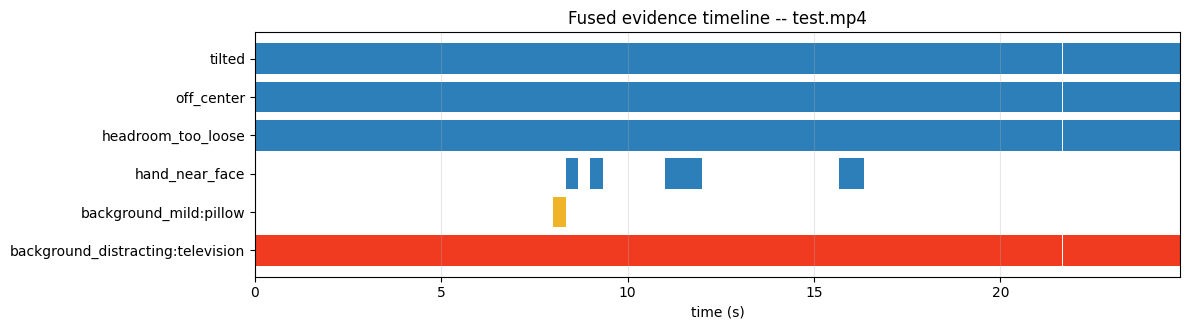

In [7]:
ALL_FLAG_TYPES = sorted({flag for pt in fused_timeline for flag in pt["flags"]})
step = 1.0 / FUSION_FPS

fig, ax = plt.subplots(figsize=(12, max(2, 0.4 * len(ALL_FLAG_TYPES) + 1)))
for row, flag_type in enumerate(ALL_FLAG_TYPES):
    spans = [(pt["timestamp_s"], step) for pt in fused_timeline if flag_type in pt["flags"]]
    color = "#f03b20" if flag_type.startswith("background_distracting") else (
        "#f0b429" if flag_type.startswith("background_mild") else "#2c7fb8"
    )
    ax.broken_barh(spans, (row - 0.4, 0.8), facecolors=color)

ax.set_yticks(range(len(ALL_FLAG_TYPES)))
ax.set_yticklabels(ALL_FLAG_TYPES)
ax.set_xlabel("time (s)")
ax.set_xlim(0, video_duration_s)
ax.set_title(f"Fused evidence timeline -- {DEMO_VIDEO_PATH.name}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fused_evidence_timeline.png", dpi=120)
plt.show()

## 8. Summary

In [8]:
flag_counts = pd.Series([flag for pt in fused_timeline for flag in pt["flags"]]).value_counts()
summary = pd.DataFrame({
    "Metric": ["Video", "Duration (s)", "Fusion FPS", "Fused timestamps", "Timestamps with >=1 flag"],
    "Value": [
        DEMO_VIDEO_PATH.name,
        f"{video_duration_s:.2f}",
        FUSION_FPS,
        len(fused_timeline),
        sum(1 for pt in fused_timeline if pt["flags"]),
    ],
})
print(summary.to_string(index=False))
print()
print("Flag counts:")
print(flag_counts.to_string())

                  Metric    Value
                   Video test.mp4
            Duration (s)    24.82
              Fusion FPS        3
        Fused timestamps       75
Timestamps with >=1 flag       75

Flag counts:
headroom_too_loose                   75
off_center                           75
tilted                               75
background_distracting:television    75
hand_near_face                        7
background_mild:pillow                1
